In [ ]:
import os

root = '/content/drive/MyDrive/ML4CC—wildfire/'

for dirpath, dirnames, filenames in os.walk(root):
    for f in filenames:
        if '104' in f or 'Temperature' in f or 'Precipitation' in f or 'NDVI' in f:
            print(os.path.join(dirpath, f))

/content/drive/MyDrive/ML4CC—wildfire/Temperature data preprocessing
/content/drive/MyDrive/ML4CC—wildfire/Weekly_NDVI_5States_2024_clean.csv
/content/drive/MyDrive/ML4CC—wildfire/Weekly_NDVI_5States_2023_clean.csv
/content/drive/MyDrive/ML4CC—wildfire/Weekly_NDVI_5States_2024_clean.gsheet
/content/drive/MyDrive/ML4CC—wildfire/Final_Weekly_Temperature_Data.csv
/content/drive/MyDrive/ML4CC—wildfire/NDVI_104weeks.csv
/content/drive/MyDrive/ML4CC—wildfire/Temperature_104weeks.csv
/content/drive/MyDrive/ML4CC—wildfire/Precipitation_104weeks.csv
/content/drive/MyDrive/ML4CC—wildfire/DATA_first round/Precipitation_combined.csv
/content/drive/MyDrive/ML4CC—wildfire/DATA_first round/Temperature_combined.csv
/content/drive/MyDrive/ML4CC—wildfire/DATA_first round/NDVI_AZ_data_final.csv
/content/drive/MyDrive/ML4CC—wildfire/DATA_first round/NDVI_CA_data_final.csv
/content/drive/MyDrive/ML4CC—wildfire/DATA_first round/NDVI_TX_data_final.csv
/content/drive/MyDrive/ML4CC—wildfire/DATA_first round/ND

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ML4CC—wildfire/'

FIRE_BASE = '/content/drive/MyDrive/ML4CC—wildfire/DATA_final/'
STATES    = ['California', 'Minnesota', 'Texas', 'Arizona', 'Washington']

temp_df = pd.read_csv(BASE + 'Temperature_104weeks.csv')
prec_df = pd.read_csv(BASE + 'Precipitation_104weeks.csv')
ndvi_df = pd.read_csv(BASE + 'NDVI_104weeks.csv')

for d in [temp_df, prec_df, ndvi_df]:
    d['week'] = d['week'].astype(int)
    d['year'] = d['year'].astype(int)

ndvi_df = ndvi_df.rename(columns={'ndvi_mean': 'ndvi'})

# Merge temp + precip + NDVI
df = pd.merge(temp_df, prec_df, on=['year', 'week', 'state', 'county'], how='inner')
df = pd.merge(df, ndvi_df,     on=['year', 'week', 'state', 'county'], how='left')

# Load all fire CSVs (from DATA_final)
fire_dfs = []
for state in STATES:
    fire_dfs.append(pd.read_csv(FIRE_BASE + f'{state}_fire.csv'))

fire_all = pd.concat(fire_dfs, ignore_index=True)
fire_all['week'] = fire_all['week'].astype(int)
fire_all['year'] = fire_all['year'].astype(int)
fire_all = fire_all[['state', 'county', 'year', 'week']].drop_duplicates()
fire_all['fire'] = 1

df = pd.merge(df, fire_all, on=['year', 'week', 'state', 'county'], how='left')
df['fire'] = df['fire'].fillna(0).astype(int)

df = df.sort_values(['state', 'year', 'week', 'county']).reset_index(drop=True)
df = df[['year', 'week', 'state', 'county', 'temperature', 'precipitation', 'ndvi', 'fire']]

out_path = FIRE_BASE + 'final_combined_104weeks.csv'
df.to_csv(out_path, index=False)

print(f"✓ Saved → {out_path}")
print(f"\nShape : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Weeks : {df['week'].min()} – {df['week'].max()}")
print(f"\nFire distribution:")
print(df['fire'].value_counts().rename({0:'No Fire (0)', 1:'Fire (1)'}).to_string())
print(f"\nFire rate by state:")
print(df.groupby('state')['fire'].agg(
    Total='count', Fires='sum',
    Fire_Rate=lambda x: f"{x.mean()*100:.2f}%"
).to_string())
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
print(f"\nPreview:\n{df.head(8).to_string(index=False)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Saved → /content/drive/MyDrive/ML4CC—wildfire/DATA_final/final_combined_104weeks.csv

Shape : 47,112 rows × 8 cols
Weeks : 1 – 104

Fire distribution:
fire
No Fire (0)    44324
Fire (1)        2788

Fire rate by state:
            Total  Fires Fire_Rate
state                             
Arizona      1560    368    23.59%
California   6032    375     6.22%
Minnesota    9048    457     5.05%
Texas       26416   1173     4.44%
Washington   4056    415    10.23%

Missing values:
year             0
week             0
state            0
county           0
temperature      0
precipitation    0
ndvi             0
fire             0

Preview:
 year  week   state   county  temperature  precipitation     ndvi  fire
 2023     1 Arizona   Apache     5.039511       2.031610 0.060670     0
 2023     1 Arizona  Cochise    14.098778       2.227286 0.144461     0
 2023     

Mounted at /content/drive
DATASET OVERVIEW
Shape          : 47,112 rows × 10 cols
Years          : [np.int64(2023), np.int64(2024)]
Weeks          : 1 – 104
States         : ['Arizona', 'California', 'Minnesota', 'Texas', 'Washington']
Total counties : 432

Fire=1 : 2,788  (5.92%)
Fire=0 : 44,324  (94.08%)

Missing values:
year             0
week             0
state            0
county           0
temperature      0
precipitation    0
ndvi             0
fire             0
week_sin         0
week_cos         0

Descriptive stats:
       temperature  precipitation       ndvi       fire
count    47112.000      47112.000  47112.000  47112.000
mean        22.250          2.071      0.275      0.059
std         10.786          3.455      0.156      0.236
min        -18.203          0.000     -0.266      0.000
25%         15.857          0.089      0.161      0.000
50%         23.510          0.716      0.260      0.000
75%         30.307          2.581      0.380      0.000
max         45.72

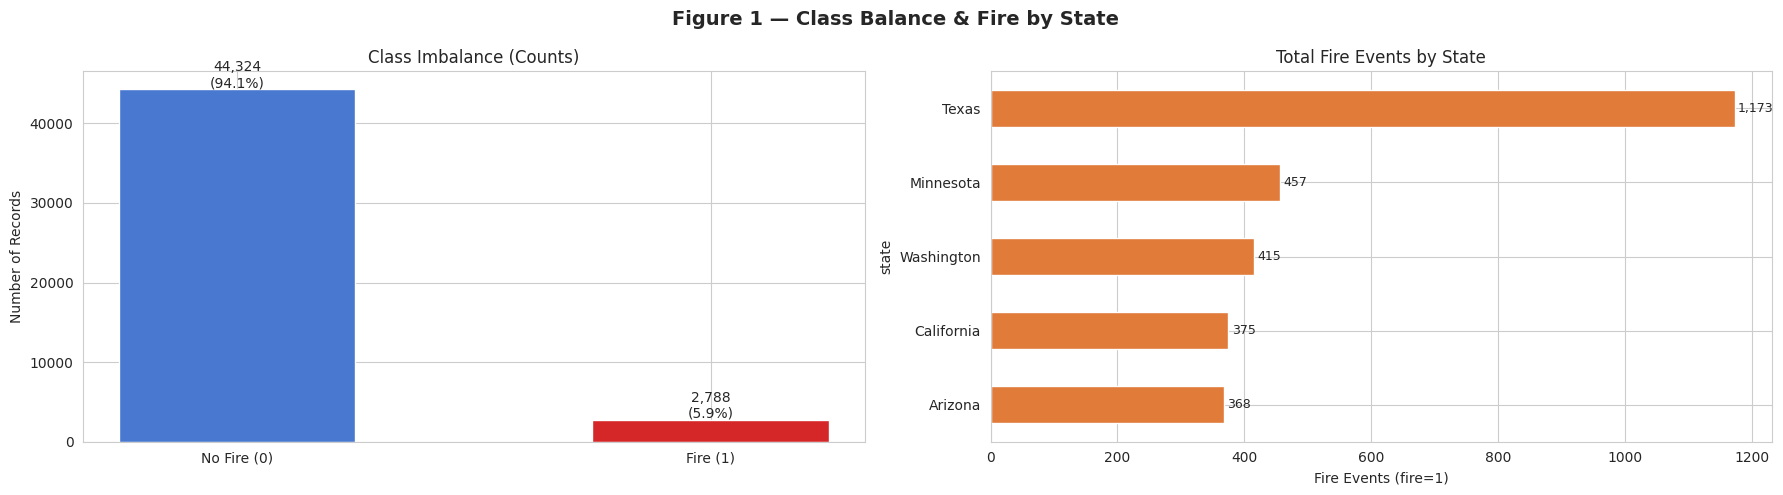

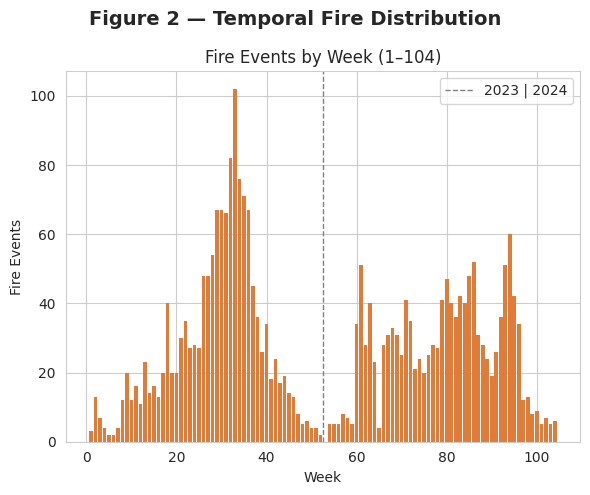

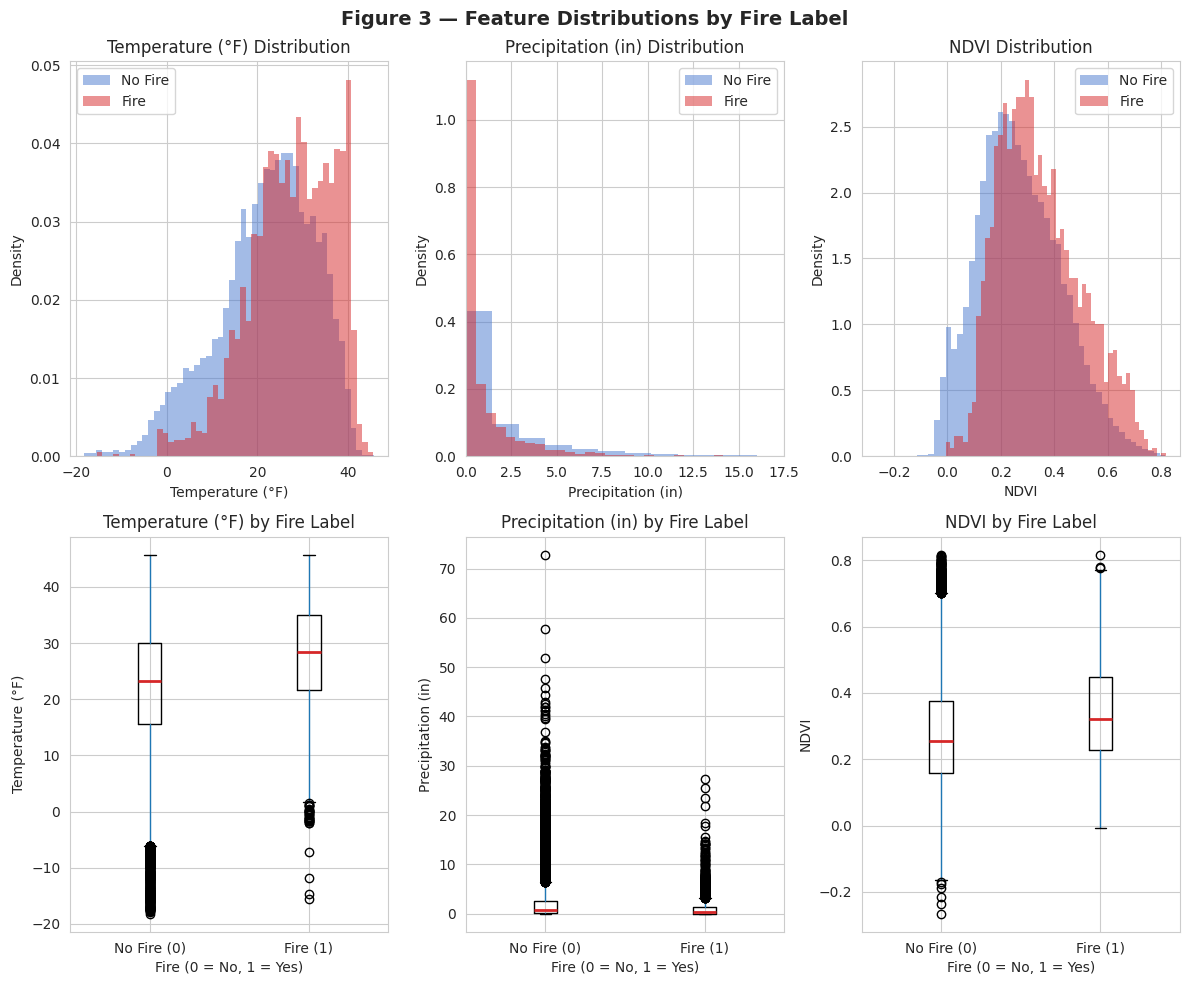

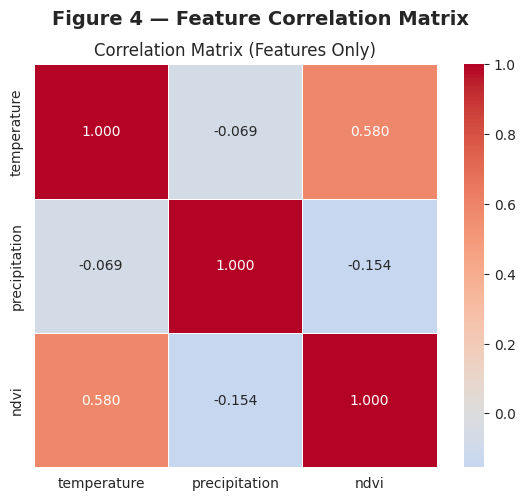


✓ All figures saved to DATA_final folder


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE = '/content/drive/MyDrive/ML4CC—wildfire/DATA_final/'
df = pd.read_csv(BASE + 'final_combined_104weeks.csv')

df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)


print("DATASET OVERVIEW")

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Years          : {sorted(df['year'].unique())}")
print(f"Weeks          : {df['week'].min()} – {df['week'].max()}")
print(f"States         : {sorted(df['state'].unique())}")
print(f"Total counties : {df['county'].nunique()}")
print(f"\nFire=1 : {df['fire'].sum():,}  ({df['fire'].mean()*100:.2f}%)")
print(f"Fire=0 : {(df['fire']==0).sum():,}  ({(1-df['fire'].mean())*100:.2f}%)")
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
print(f"\nDescriptive stats:")
print(df[['temperature','precipitation','ndvi','fire']].describe().round(3).to_string())

C0, C1 = '#4878cf', '#d62728'
sns.set_style("whitegrid")

# FIGURE 1: Class imbalance + Fire by State
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Figure 1 — Class Balance & Fire by State', fontsize=14, fontweight='bold')

counts = df['fire'].value_counts().sort_index()
bars = axes[0].bar(['No Fire (0)', 'Fire (1)'], counts.values,
                   color=[C0, C1], edgecolor='white', width=0.5)
axes[0].set_title('Class Imbalance (Counts)')
axes[0].set_ylabel('Number of Records')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)


state_counts = df.groupby('state')['fire'].sum().sort_values(ascending=True)
state_counts.plot(kind='barh', ax=axes[1], color='#e07b39', edgecolor='white')
axes[1].set_title('Total Fire Events by State')
axes[1].set_xlabel('Fire Events (fire=1)')
for i, v in enumerate(state_counts.values):
    axes[1].text(v+5, i, f'{int(v):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE + 'fig1_class_state.png', dpi=150)
plt.show()


# FIGURE 2: Fire by Week (1-104) + by Year
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle('Figure 2 — Temporal Fire Distribution', fontsize=14, fontweight='bold')

# Fire count across all 104 weeks
weekly = df.groupby('week')['fire'].sum()
ax.bar(weekly.index, weekly.values, color='#e07b39', edgecolor='none', width=0.8)

ax.set_title('Fire Events by Week (1–104)')
ax.set_xlabel('Week')
ax.set_ylabel('Fire Events')

ax.axvline(x=52.5, color='gray', linestyle='--', linewidth=1, label='2023 | 2024')
ax.legend()

plt.tight_layout()
plt.savefig(BASE + 'fig2_temporal_fire.png', dpi=150)
plt.show()


# FIGURE 3: Feature distributions vs Fire
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
fig.suptitle('Figure 3 — Feature Distributions by Fire Label', fontsize=14, fontweight='bold')

features = ['temperature', 'precipitation', 'ndvi']
titles   = ['Temperature (°F)', 'Precipitation (in)', 'NDVI']

for i, (feat, title) in enumerate(zip(features, titles)):

    for label, color, name in [(0, C0, 'No Fire'), (1, C1, 'Fire')]:
        subset = df[df['fire'] == label][feat].dropna()
        axes[0][i].hist(subset, bins=50, alpha=0.5, color=color,
                        label=name, density=True, edgecolor='none')

    axes[0][i].set_title(f'{title} Distribution')
    axes[0][i].set_xlabel(title)
    axes[0][i].set_ylabel('Density')
    axes[0][i].legend()

    if feat == 'precipitation':
        axes[0][i].set_xlim(0, 17.5)

    df.boxplot(column=feat, by='fire', ax=axes[1][i],
               boxprops=dict(color='black'),
               medianprops=dict(color=C1, linewidth=2))

    axes[1][i].set_title(f'{title} by Fire Label')
    axes[1][i].set_xlabel('Fire (0 = No, 1 = Yes)')
    axes[1][i].set_ylabel(title)

    plt.sca(axes[1][i])
    plt.xticks([1, 2], ['No Fire (0)', 'Fire (1)'])

plt.suptitle('Figure 3 — Feature Distributions by Fire Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'fig4_features_vs_fire.png', dpi=150)
plt.show()

# FIGURE 4: Correlation matrix

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle('Figure 4 — Feature Correlation Matrix', fontsize=14, fontweight='bold')

corr = df[['temperature', 'precipitation', 'ndvi']].corr()

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

ax.set_title('Correlation Matrix (Features Only)')

plt.tight_layout()
plt.savefig(BASE + 'fig4_correlation.png', dpi=150)
plt.show()
print("\n✓ All figures saved to DATA_final folder")

In [ ]:
import pandas as pd

BASE = '/content/drive/MyDrive/ML4CC—wildfire/DATA_final/'
df = pd.read_csv(BASE + 'final_combined_104weeks.csv')
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

df['time_index'] = df['year'] * 53 + df['week']

df = df.sort_values(['state', 'county', 'time_index']).reset_index(drop=True)

features = ['temperature', 'precipitation', 'ndvi', 'week_sin', 'week_cos']
target = 'fire'

rows = []

for (state, county), g in df.groupby(['state', 'county']):
    g = g.sort_values('time_index').reset_index(drop=True)

    for i in range(3, len(g)):
        if list(g.loc[i-3:i, 'time_index']) != list(range(g.loc[i-3, 'time_index'], g.loc[i-3, 'time_index'] + 4)):
            continue

        row = {
            'state': state,
            'county': county,
            'year': g.loc[i, 'year'],
            'week': g.loc[i, 'week'],
            'time_index': g.loc[i, 'time_index'],
            'target_fire': g.loc[i, target]
        }

        row['fire_lag1'] = g.loc[i-1, 'fire']
        row['fire_lag2'] = g.loc[i-2, 'fire']
        row['fire_lag3'] = g.loc[i-3, 'fire']

        for lag in [3, 2, 1]:
            past = g.loc[i-lag]
            for f in features:
                row[f'{f}_lag{lag}'] = past[f]

        rows.append(row)

model_df = pd.DataFrame(rows)
print("model_df shape:", model_df.shape)
print(model_df.head())

model_df shape: (44394, 24)
     state  county  year  week  time_index  target_fire  fire_lag1  fire_lag2  \
0  Arizona  Apache  2023     4      107223            0          0          0   
1  Arizona  Apache  2023     5      107224            0          0          0   
2  Arizona  Apache  2023     6      107225            0          0          0   
3  Arizona  Apache  2023     7      107226            0          0          0   
4  Arizona  Apache  2023     8      107227            0          0          0   

   fire_lag3  temperature_lag3  ...  temperature_lag2  precipitation_lag2  \
0          0          5.039511  ...         10.492707            0.461143   
1          0         10.492707  ...          2.390399            2.864701   
2          0          2.390399  ...          3.075635            0.212441   
3          0          3.075635  ...          7.289319            0.062517   
4          0          7.289319  ...          7.202835            0.371182   

   ndvi_lag2  week_sin

In [ ]:
import numpy as np
import pandas as pd

lag_features = [

    'fire_lag1','fire_lag2', 'fire_lag3',

    'temperature_lag3', 'precipitation_lag3', 'ndvi_lag3',
    'week_sin_lag3', 'week_cos_lag3',

    'temperature_lag2', 'precipitation_lag2', 'ndvi_lag2',
    'week_sin_lag2', 'week_cos_lag2',

    'temperature_lag1', 'precipitation_lag1', 'ndvi_lag1',
    'week_sin_lag1', 'week_cos_lag1'
]

# Sort by real time
model_df = model_df.sort_values(['time_index', 'state', 'county']).reset_index(drop=True)

# Test = future year
train = model_df[model_df['year'] == 2023].copy()
test  = model_df[model_df['year'] == 2024].copy()

# Validation = later part of 2023, not random
train = train.sort_values(['time_index', 'state', 'county']).reset_index(drop=True)

split_idx = int(len(train) * 0.8)

train_part = train.iloc[:split_idx].copy()
val_part   = train.iloc[split_idx:].copy()

X_tr  = train_part[lag_features]
y_tr  = train_part['target_fire']

X_val = val_part[lag_features]
y_val = val_part['target_fire']

X_test = test[lag_features]
y_test = test['target_fire']

# for class_weight / scale_pos_weight
X_train = train[lag_features]
y_train = train['target_fire']

print("Train part:", X_tr.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print("Pos rate (train part):", y_tr.mean())
print("Pos rate (validation):", y_val.mean())
print("Pos rate (test):", y_test.mean())

Train part: (18120, 18) Validation: (4530, 18) Test: (21744, 18)
Pos rate (train part): 0.07417218543046358
Pos rate (validation): 0.016556291390728478
Pos rate (test): 0.06121228844738778


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# scale for LR
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Naive LR
lr_naive = LogisticRegression(max_iter=1000)
lr_naive.fit(X_tr_s, y_tr)
prob_lr_naive = lr_naive.predict_proba(X_test_s)[:,1]

# Balanced LR
lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_bal.fit(X_tr_s, y_tr)
prob_lr_bal_val = lr_bal.predict_proba(X_val_s)[:,1]
prob_lr_bal     = lr_bal.predict_proba(X_test_s)[:,1]

# XGBoost
from xgboost import XGBClassifier

scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb.fit(X_tr, y_tr)
prob_xgb_val = xgb.predict_proba(X_val)[:,1]
prob_xgb     = xgb.predict_proba(X_test)[:,1]

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import StandardScaler
import numpy as np

gru_features = [

    # t-3
    'temperature_lag3',
    'precipitation_lag3',
    'ndvi_lag3',
    'week_sin_lag3',
    'week_cos_lag3',
    'fire_lag3',

    # t-2
    'temperature_lag2',
    'precipitation_lag2',
    'ndvi_lag2',
    'week_sin_lag2',
    'week_cos_lag2',
    'fire_lag2',

    # t-1
    'temperature_lag1',
    'precipitation_lag1',
    'ndvi_lag1',
    'week_sin_lag1',
    'week_cos_lag1',
    'fire_lag1'
]

X_tr_gru = X_tr[gru_features]
X_val_gru = X_val[gru_features]
X_test_gru = X_test[gru_features]

# reshape into sequence format
X_tr_seq = X_tr_gru.values.reshape(-1, 3, 6)
X_val_seq = X_val_gru.values.reshape(-1, 3, 6)
X_test_seq = X_test_gru.values.reshape(-1, 3, 6)

# scale
scaler_seq = StandardScaler()

X_tr_seq = scaler_seq.fit_transform(
    X_tr_seq.reshape(-1, 6)
).reshape(-1, 3, 6)

X_val_seq = scaler_seq.transform(
    X_val_seq.reshape(-1, 6)
).reshape(-1, 3, 6)

X_test_seq = scaler_seq.transform(
    X_test_seq.reshape(-1, 6)
).reshape(-1, 3, 6)

# class weight
neg, pos = np.bincount(y_tr)
cw = {0:1.0, 1:neg/max(pos,1)}

# GRU model
gru = Sequential([
    Input(shape=(3, 6)),
    GRU(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

gru.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

gru.fit(
    X_tr_seq,
    y_tr,
    epochs=8,
    batch_size=64,
    validation_data=(X_val_seq, y_val),
    class_weight=cw,
    verbose=1
)

prob_gru_val = gru.predict(X_val_seq).flatten()
prob_gru = gru.predict(X_test_seq).flatten()

Epoch 1/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.0195 - val_loss: 0.2825
Epoch 2/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9624 - val_loss: 0.1970
Epoch 3/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.9552 - val_loss: 0.1733
Epoch 4/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9413 - val_loss: 0.1983
Epoch 5/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9386 - val_loss: 0.1681
Epoch 6/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9340 - val_loss: 0.1758
Epoch 7/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9342 - val_loss: 0.1569
Epoch 8/8
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9263 - val_loss: 0.1590
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
680/680 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

def pick_threshold(y_true, y_prob, target_recall=0.6):
    p, r, t = precision_recall_curve(y_true, y_prob)

    # thresholds t has length len(r)-1, so match r[:-1]
    valid = np.where(r[:-1] >= target_recall)[0]

    if len(valid) == 0:
        return 0.5

    # highest threshold that still keeps recall >= target
    return t[valid[-1]]

thr_lr_naive = 0.5
thr_lr_bal = pick_threshold(y_val, prob_lr_bal_val, 0.6)
thr_xgb    = pick_threshold(y_val, prob_xgb_val, 0.6)
thr_gru    = pick_threshold(y_val, prob_gru_val, 0.6)

print("Thresholds:",
      thr_lr_naive, thr_lr_bal, thr_xgb, thr_gru)

Thresholds: 0.5 0.25977527985629517 0.10464251 0.17034805


In [ ]:
from lightgbm import LGBMClassifier

scale_pos_weight = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

lgb = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgb.fit(X_tr, y_tr)

prob_lgb_val = lgb.predict_proba(X_val)[:, 1]
prob_lgb = lgb.predict_proba(X_test)[:, 1]

thr_lgb = pick_threshold(y_val, prob_lgb_val, target_recall=0.6)


[LightGBM] [Info] Number of positive: 1344, number of negative: 16776
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2504
[LightGBM] [Info] Number of data points in the train set: 18120, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.074172 -> initscore=-2.524299
[LightGBM] [Info] Start training from score -2.524299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain


=== Naive LR (thr=0.50) ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     20413
           1       0.66      0.17      0.27      1331

    accuracy                           0.94     21744
   macro avg       0.80      0.58      0.62     21744
weighted avg       0.93      0.94      0.93     21744

ROC-AUC: 0.8026450270729865

=== Balanced LR (thr=0.26) ===
              precision    recall  f1-score   support

           0       0.98      0.44      0.60     20413
           1       0.09      0.86      0.16      1331

    accuracy                           0.46     21744
   macro avg       0.54      0.65      0.38     21744
weighted avg       0.93      0.46      0.58     21744

ROC-AUC: 0.8019583062796085

=== XGBoost (thr=0.10) ===
              precision    recall  f1-score   support

           0       0.97      0.52      0.67     20413
           1       0.10      0.79      0.17      1331

    accuracy                         

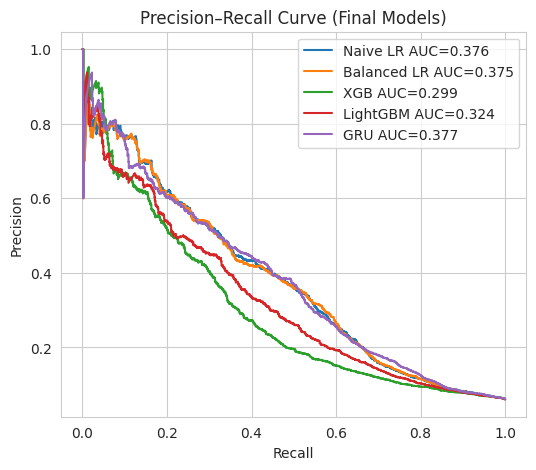

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc
)
def evaluate(name, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    print(f"\n=== {name} (thr={thr:.2f}) ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

def pr_auc(y_true, y_prob):
    p, r, _ = precision_recall_curve(y_true, y_prob)
    return auc(r, p), r, p

# evaluate
evaluate("Naive LR", y_test, prob_lr_naive, thr_lr_naive)
evaluate("Balanced LR", y_test, prob_lr_bal, thr_lr_bal)
evaluate("XGBoost", y_test, prob_xgb, thr_xgb)
evaluate("LightGBM", y_test, prob_lgb, thr_lgb)
evaluate("GRU", y_test, prob_gru, thr_gru)

# PR curve
plt.figure(figsize=(6,5))

for name, prob in [
    ("Naive LR", prob_lr_naive),
    ("Balanced LR", prob_lr_bal),
    ("XGB", prob_xgb),
    ("LightGBM", prob_lgb),
    ("GRU", prob_gru)
]:
    auc_val, r, p = pr_auc(y_test, prob)
    plt.plot(r, p, label=f"{name} AUC={auc_val:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Final Models)")
plt.legend()
plt.grid(True)
plt.show()

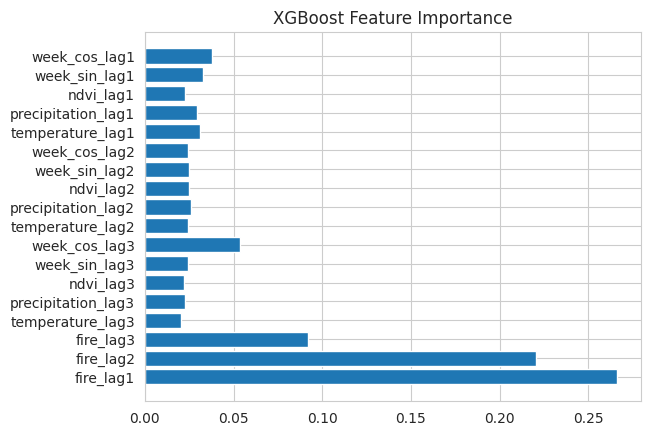

In [ ]:
# feature importance for XGBoost
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
plt.barh(lag_features, importances)
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
# Grid search ensemble weight using validation set

best_f1 = -1
best_w = None
best_thr = None

for w in np.linspace(0, 1, 11):
    # w = LR weight, 1-w = XGB weight
    prob_val = w * prob_lr_bal_val + (1 - w) * prob_xgb_val

    thr = pick_threshold(y_val, prob_val, target_recall=0.6)
    y_pred_val = (prob_val >= thr).astype(int)

    report = classification_report(
        y_val, y_pred_val,
        output_dict=True,
        zero_division=0
    )

    f1_fire = report['1']['f1-score']

    if f1_fire > best_f1:
        best_f1 = f1_fire
        best_w = w
        best_thr = thr

print("Best LR weight:", best_w)
print("Best XGB weight:", 1 - best_w)
print("Best validation threshold:", best_thr)
print("Best validation fire F1:", best_f1)

# Apply best ensemble to test set
prob_ensemble = best_w * prob_lr_bal + (1 - best_w) * prob_xgb
y_pred_ens = (prob_ensemble >= best_thr).astype(int)

print("\n=== Optimized Ensemble: Balanced LR + XGBoost ===")
print(classification_report(y_test, y_pred_ens, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, prob_ensemble))

p_ens, r_ens, _ = precision_recall_curve(y_test, prob_ensemble)
print("PR-AUC:", auc(r_ens, p_ens))

Best LR weight: 1.0
Best XGB weight: 0.0
Best validation threshold: 0.25977527985629517
Best validation fire F1: 0.10869565217391304

=== Optimized Ensemble: Balanced LR + XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.44      0.60     20413
           1       0.09      0.86      0.16      1331

    accuracy                           0.46     21744
   macro avg       0.54      0.65      0.38     21744
weighted avg       0.93      0.46      0.58     21744

ROC-AUC: 0.8019583062796085
PR-AUC: 0.3747936091212366


In [ ]:
import pandas as pd

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    accuracy_score
)

def get_metrics(y_true, y_prob, thr):

    y_pred = (y_prob >= thr).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    p, r, _ = precision_recall_curve(y_true, y_prob)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1": report['1']['f1-score'],
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": auc(r, p)
    }

results = []

models = [
    ("Naive LR", prob_lr_naive, thr_lr_naive),
    ("Balanced LR", prob_lr_bal, thr_lr_bal),
    ("XGBoost", prob_xgb, thr_xgb),
    ("LightGBM", prob_lgb, thr_lgb),
    ("GRU", prob_gru, thr_gru),
]

for name, prob, thr in models:

    m = get_metrics(y_test, prob, thr)
    m["Model"] = name
    results.append(m)

results_df = pd.DataFrame(results)

results_df = results_df[
    ["Model","Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC"]
]

print("\nFINAL MODEL COMPARISON")

print(
    results_df
    .sort_values("F1", ascending=False)
    .round(3)
)


FINAL MODEL COMPARISON
         Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
0     Naive LR     0.944      0.658   0.171  0.271    0.803   0.376
2      XGBoost     0.533      0.096   0.793  0.172    0.755   0.299
3     LightGBM     0.501      0.095   0.835  0.170    0.780   0.324
1  Balanced LR     0.463      0.091   0.863  0.164    0.802   0.375
4          GRU     0.347      0.079   0.911  0.146    0.809   0.377


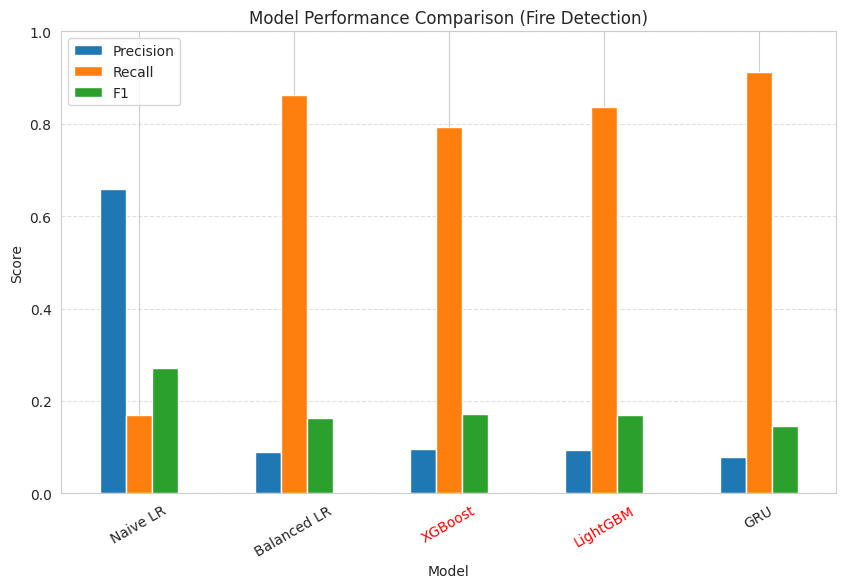

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1"]

ax = results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison (Fire Detection)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0,1)

# highlight tree models
for i, model in enumerate(results_df["Model"]):
    if "XGBoost" in model or "LightGBM" in model:
        ax.get_xticklabels()[i].set_color("red")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

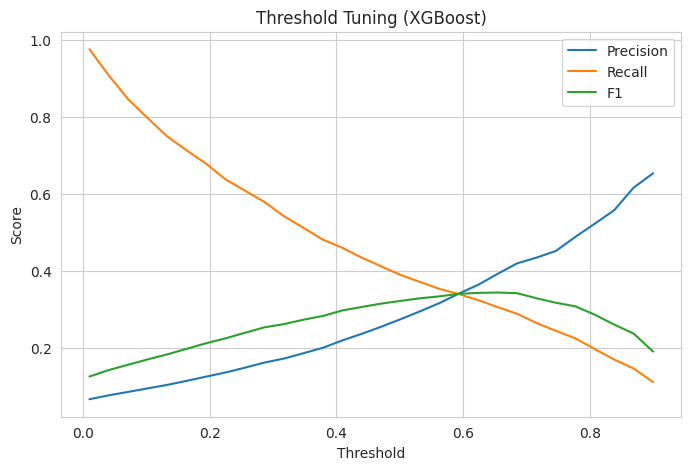

In [ ]:
thresholds = np.linspace(0.01, 0.9, 30)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred = (prob_xgb >= t).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    precisions.append(report['1']['precision'])
    recalls.append(report['1']['recall'])
    f1s.append(report['1']['f1-score'])

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

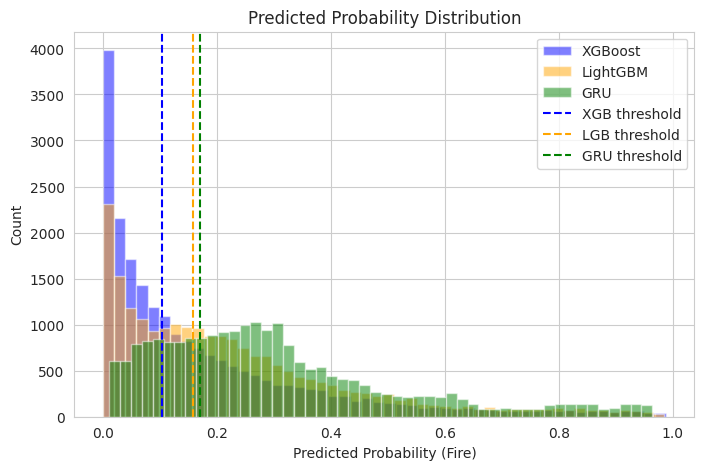

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(prob_xgb, color = 'blue',  bins=50, alpha=0.5, label="XGBoost")
plt.hist(prob_lgb, color = 'orange', bins=50, alpha=0.5, label="LightGBM")
plt.hist(prob_gru, color = 'green',bins=50, alpha=0.5, label="GRU")

plt.axvline(thr_xgb, color = 'blue', linestyle='--', label="XGB threshold")
plt.axvline(thr_lgb, color = 'orange', linestyle='--', label="LGB threshold")
plt.axvline(thr_gru, color = 'green',linestyle='--', label="GRU threshold")

plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability (Fire)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# XGBoost predictions
y_pred_xgb = (prob_xgb >= thr_xgb).astype(int)

#  attach prediction to test df
analysis_df = test.copy()

analysis_df["y_true"] = y_test.values
analysis_df["y_pred"] = y_pred_xgb

# Group 1: previous 3 weeks all no fire
group_no_fire = analysis_df[
    (analysis_df["fire_lag1"] == 0) &
    (analysis_df["fire_lag2"] == 0) &
    (analysis_df["fire_lag3"] == 0)
]

# Group 2: at least one previous fire
group_has_fire = analysis_df[
    (analysis_df["fire_lag1"] == 1) |
    (analysis_df["fire_lag2"] == 1) |
    (analysis_df["fire_lag3"] == 1)
]

def print_metrics(name, df_group):

    report = classification_report(
        df_group["y_true"],
        df_group["y_pred"],
        output_dict=True,
        zero_division=0
    )

    print(f"{name}")

    print("Samples:", len(df_group))
    print("Fire Recall:", round(report["1"]["recall"], 3))
    print("Fire Precision:", round(report["1"]["precision"], 3))
    print("Fire F1:", round(report["1"]["f1-score"], 3))

print_metrics("Previous 3 Weeks = No Fire", group_no_fire)

print_metrics("Previous Fire Exists", group_has_fire)

Previous 3 Weeks = No Fire
Samples: 18983
Fire Recall: 0.639
Fire Precision: 0.04
Fire F1: 0.074
Previous Fire Exists
Samples: 2761
Fire Recall: 0.897
Fire Precision: 0.315
Fire F1: 0.467


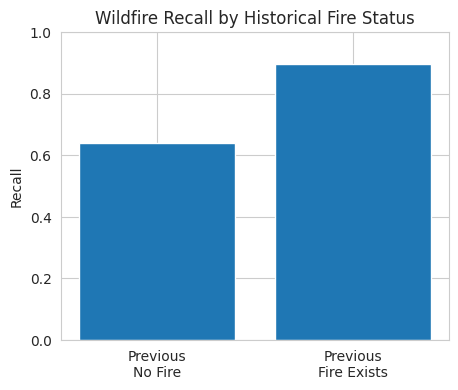

In [ ]:
import matplotlib.pyplot as plt

groups = [
    "Previous\nNo Fire",
    "Previous\nFire Exists"
]

recalls = [
    classification_report(
        group_no_fire["y_true"],
        group_no_fire["y_pred"],
        output_dict=True,
        zero_division=0
    )["1"]["recall"],

    classification_report(
        group_has_fire["y_true"],
        group_has_fire["y_pred"],
        output_dict=True,
        zero_division=0
    )["1"]["recall"]
]

plt.figure(figsize=(5,4))

plt.bar(groups, recalls)

plt.ylabel("Recall")
plt.ylim(0,1)

plt.title("Wildfire Recall by Historical Fire Status")

plt.show()